<a href="https://colab.research.google.com/github/maikol0629/dl_voice_command_cl/blob/main/05_modelo_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo Transformer: Spectrogram Encoder con RoPE para Clasificación de Comandos de Voz

In [1]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
        os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn librosa soundfile audioread numba
    import kagglehub
    import shutil

    try:
        data_path = kagglehub.competition_download("voice-commands-classification-2026")
    except Exception as e:
        print("Error al descargar de Kaggle. Asegúrate de configurar KAGGLE_USERNAME y KAGGLE_KEY en tus Colab Secrets.")
        raise e

    if not os.path.exists('data'):
        os.symlink(data_path, 'data')

    if not os.path.exists('dl_voice_command_cl'):
        !git clone https://github.com/maikol0629/dl_voice_command_cl.git

    for f in ['train_metadata.csv', 'test_metadata.csv']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')

    DATA_PATH = os.path.join(data_path, 'train')
else:
    DATA_PATH = './data/train'


100%|██████████| 3.31G/3.31G [00:30<00:00, 119MB/s]

Extracting files...


Cloning into 'dl_voice_command_cl'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 41 (delta 18), reused 27 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 2.18 MiB | 15.97 MiB/s, done.
Resolving deltas: 100% (18/18), done.


In [2]:
import os
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [3]:
SAMPLE_RATE = 16000
BATCH_SIZE = 64
EPOCHS = 30
LR = 0.001
N_CLASSES = 35
N_MFCC = 120
D_MODEL = 120
N_HEADS = 6
N_LAYERS = 4
D_FF = D_MODEL * 4
MAX_SEQ_LEN = 256
PATIENCE = 5
SEED = 42
VAL_SIZE = 0.2

np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
class VoiceCommandsDataset(Dataset):
    def __init__(self, df, audio_dir, max_samples=16000, n_mfcc=120, sample_rate=16000):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.max_samples = max_samples
        self.mfcc = T.MFCC(
            sample_rate=sample_rate,
            n_mfcc=n_mfcc,
            log_mels=True
        )

    def __len__(self):
        return len(self.df)

    def _load_audio(self, file_name):
        file_path = self.audio_dir / file_name
        arr = np.load(file_path, allow_pickle=False)
        if isinstance(arr, np.lib.npyio.NpzFile):
            key = 'audio' if 'audio' in arr.files else arr.files[0]
            arr = arr[key]
        return np.asarray(arr).reshape(-1).astype(np.float32)

    def _pad_audio(self, audio):
        if audio.shape[0] > self.max_samples:
            return audio[:self.max_samples]
        if audio.shape[0] < self.max_samples:
            padding = self.max_samples - audio.shape[0]
            return np.pad(audio, (0, padding), mode='constant')
        return audio

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio = self._load_audio(row['filename'])
        audio = self._pad_audio(audio)
        audio_tensor = torch.from_numpy(audio).float()
        mfcc = self.mfcc(audio_tensor)
        label = int(row['label_id'])
        return mfcc, torch.tensor(label, dtype=torch.long)

In [5]:
train_df = pd.read_csv('train_metadata.csv')
train_df = train_df.dropna(subset=['label']).copy()
train_df['label'] = train_df['label'].astype(str)

label_encoder = LabelEncoder()
train_df['label_id'] = label_encoder.fit_transform(train_df['label'])
num_classes = len(label_encoder.classes_)

train_split_df, val_split_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_df['label_id']
)

AUDIO_DIR = os.path.join(DATA_PATH, 'train', 'train')

train_dataset = VoiceCommandsDataset(train_split_df, AUDIO_DIR)
val_dataset = VoiceCommandsDataset(val_split_df, AUDIO_DIR)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print(f"Total muestras: {len(train_df)}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Numero de clases: {num_classes}")
print("Clases:", list(label_encoder.classes_))

Total muestras: 95246
Train: 76196 | Val: 19050
Numero de clases: 35
Clases: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [6]:
class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=256):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)
        t = torch.arange(max_seq_len, dtype=torch.float32)
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer('cos_cached', emb.cos()[None, None, :, :])
        self.register_buffer('sin_cached', emb.sin()[None, None, :, :])

    def forward(self, x, seq_len=None):
        if seq_len is None:
            seq_len = x.shape[-2]
        cos = self.cos_cached[:, :, :seq_len, :]
        sin = self.sin_cached[:, :, :seq_len, :]
        return cos, sin


def rotate_half(x):
    x1 = x[..., :x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2:]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_emb(x, cos, sin):
    return (x * cos) + (rotate_half(x) * sin)

In [7]:
class AttentionWithRoPE(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.wo = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, cos, sin):
        B, T, C = x.shape
        q = self.wq(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.wk(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.wv(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q = apply_rotary_emb(q, cos, sin)
        k = apply_rotary_emb(k, cos, sin)

        attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, T, C)
        return self.wo(out)


class SwiGLUFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff * 2)
        self.w2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.w1(x)
        x, gate = x.chunk(2, dim=-1)
        x = x * F.silu(gate)
        return self.dropout(self.w2(x))


class TransformerEncoderLayerRoPE(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = AttentionWithRoPE(d_model, n_heads, dropout)
        self.ffn = SwiGLUFFN(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, cos, sin):
        x = x + self.dropout(self.attn(self.norm1(x), cos, sin))
        x = x + self.ffn(self.norm2(x))
        return x

In [8]:
class SpectrogramTransformer(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 n_classes=N_CLASSES, max_seq_len=MAX_SEQ_LEN, dropout=0.1):
        super().__init__()
        self.rotary = RotaryEmbedding(d_model // n_heads, max_seq_len)
        self.layers = nn.ModuleList([
            TransformerEncoderLayerRoPE(d_model, n_heads, d_model * 4, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        B, T, D = x.shape
        cos, sin = self.rotary(x, seq_len=T)
        for layer in self.layers:
            x = layer(x, cos, sin)
        x = self.norm(x).mean(dim=1)
        return self.classifier(x)

In [9]:
model = SpectrogramTransformer().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametros entrenables: {total_params:,}")

SpectrogramTransformer(
  (rotary): RotaryEmbedding()
  (layers): ModuleList(
    (0-3): 4 x TransformerEncoderLayerRoPE(
      (attn): AttentionWithRoPE(
        (wq): Linear(in_features=120, out_features=120, bias=True)
        (wk): Linear(in_features=120, out_features=120, bias=True)
        (wv): Linear(in_features=120, out_features=120, bias=True)
        (wo): Linear(in_features=120, out_features=120, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffn): SwiGLUFFN(
        (w1): Linear(in_features=120, out_features=960, bias=True)
        (w2): Linear(in_features=480, out_features=120, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((120,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Linear(in

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

In [11]:
for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for mfcc, labels in train_loader:
        mfcc = mfcc.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(mfcc)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item() * mfcc.size(0)
        preds = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    scheduler.step()

    epoch_train_loss = train_loss_sum / train_total
    epoch_train_acc = train_correct / train_total

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for mfcc, labels in val_loader:
            mfcc = mfcc.to(device)
            labels = labels.to(device)
            outputs = model(mfcc)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * mfcc.size(0)
            preds = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss_sum / val_total
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_transformer.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping en epoca {epoch+1}")
            break

Epoch 01/30 | Train Loss: 1.2453 Acc: 63.79% | Val Loss: 0.4902 Acc: 85.76%
Epoch 02/30 | Train Loss: 0.4080 Acc: 88.06% | Val Loss: 0.3335 Acc: 90.35%
Epoch 03/30 | Train Loss: 0.2927 Acc: 91.48% | Val Loss: 0.2874 Acc: 91.82%
Epoch 04/30 | Train Loss: 0.2382 Acc: 92.87% | Val Loss: 0.2501 Acc: 92.83%
Epoch 05/30 | Train Loss: 0.2026 Acc: 93.93% | Val Loss: 0.2319 Acc: 93.40%
Epoch 06/30 | Train Loss: 0.1732 Acc: 94.76% | Val Loss: 0.2298 Acc: 93.62%
Epoch 07/30 | Train Loss: 0.1496 Acc: 95.52% | Val Loss: 0.2306 Acc: 93.75%
Epoch 08/30 | Train Loss: 0.1314 Acc: 95.95% | Val Loss: 0.2313 Acc: 93.74%
Epoch 09/30 | Train Loss: 0.1168 Acc: 96.41% | Val Loss: 0.2330 Acc: 94.04%
Epoch 10/30 | Train Loss: 0.1020 Acc: 96.89% | Val Loss: 0.2240 Acc: 94.32%
Epoch 11/30 | Train Loss: 0.0915 Acc: 97.17% | Val Loss: 0.2238 Acc: 94.43%
Epoch 12/30 | Train Loss: 0.0806 Acc: 97.49% | Val Loss: 0.2436 Acc: 94.61%
Epoch 13/30 | Train Loss: 0.0706 Acc: 97.85% | Val Loss: 0.2537 Acc: 94.50%
Epoch 14/30 

In [12]:
model.load_state_dict(torch.load('best_transformer.pth', map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for mfcc, labels in val_loader:
        mfcc = mfcc.to(device)
        outputs = model(mfcc)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())

val_acc_final = (np.array(y_true) == np.array(y_pred)).mean()
print(f"Accuracy final en validacion: {val_acc_final*100:.2f}%")

Accuracy final en validacion: 94.43%


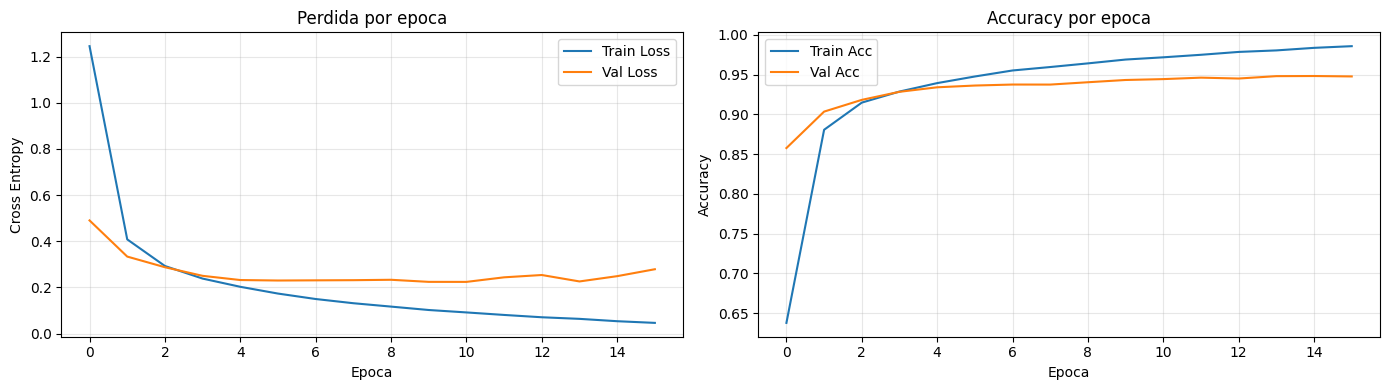

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Perdida por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross Entropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

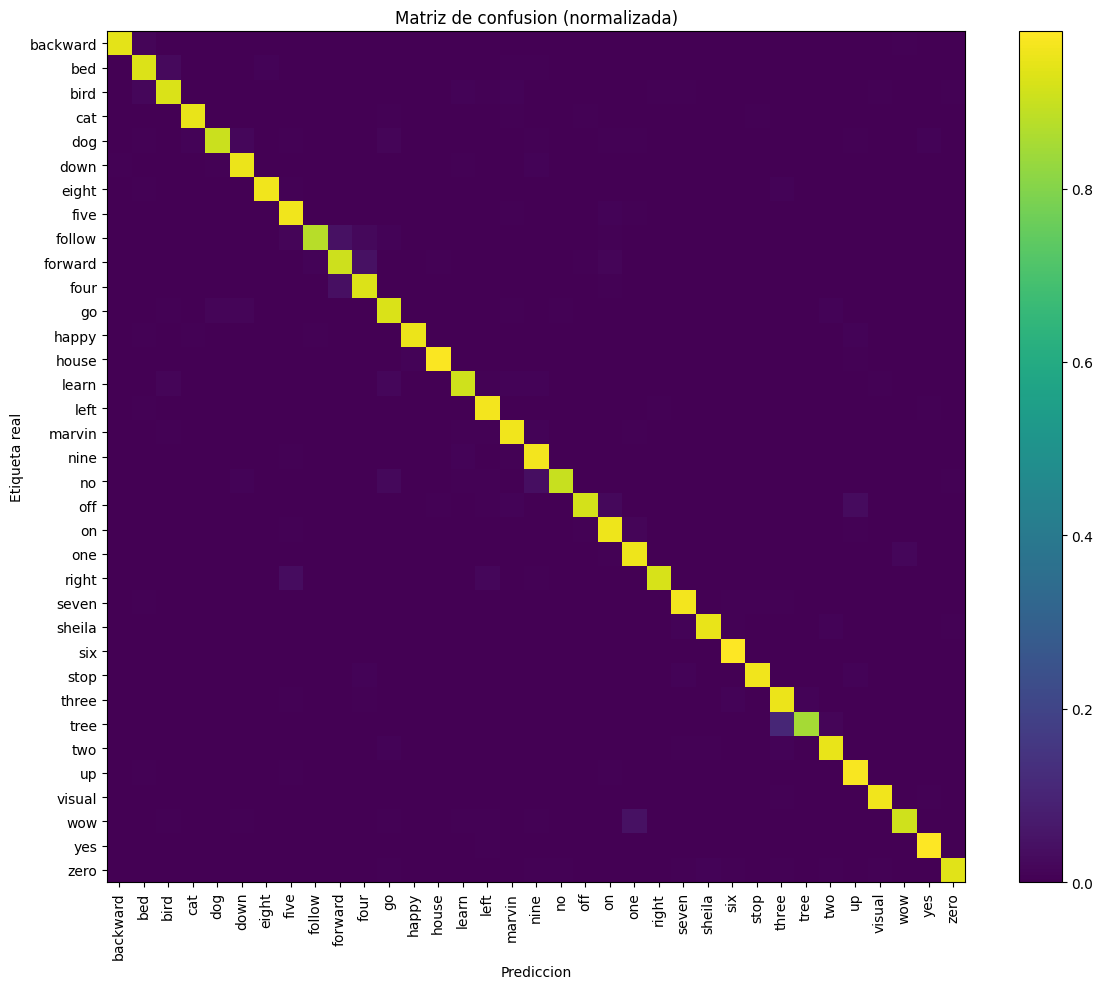

Reporte de clasificacion (validacion):
              precision    recall  f1-score   support

    backward       0.96      0.94      0.95       296
         bed       0.88      0.93      0.90       363
        bird       0.90      0.92      0.91       373
         cat       0.95      0.95      0.95       364
         dog       0.95      0.90      0.92       383
        down       0.95      0.95      0.95       702
       eight       0.97      0.96      0.97       683
        five       0.93      0.96      0.94       731
      follow       0.94      0.88      0.91       284
     forward       0.83      0.91      0.87       278
        four       0.95      0.93      0.94       674
          go       0.92      0.92      0.92       700
       happy       0.98      0.95      0.97       368
       house       0.97      0.97      0.97       381
       learn       0.88      0.91      0.90       281
        left       0.94      0.96      0.95       683
      marvin       0.89      0.96      0.9

In [14]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(12, 10))
plt.imshow(cm_norm, interpolation='nearest', aspect='auto')
plt.title('Matriz de confusion (normalizada)')
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel('Prediccion')
plt.ylabel('Etiqueta real')
plt.tight_layout()
plt.show()

print('Reporte de clasificacion (validacion):')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))